**Downloading the datasets**

In [3]:
!pip install medmnist
from medmnist import PneumoniaMNIST, BloodMNIST

pneumonia_train = PneumoniaMNIST(split="train", download=True)
pneumonia_test  = PneumoniaMNIST(split="test",  download=True)
blood_train     = BloodMNIST(split="train",     download=True)
blood_test      = BloodMNIST(split="test",      download=True)

print(pneumonia_train)
print(blood_train)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.7 MB/s eta 0:00:00


100%|██████████| 4.17M/4.17M [00:00<00:00, 4.52MB/s]
100%|██████████| 35.5M/35.5M [00:02<00:00, 16.8MB/s]


Dataset PneumoniaMNIST of size 28 (pneumoniamnist)
    Number of datapoints: 4708
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'normal', '1': 'pneumonia'}
    Number of samples: {'train': 4708, 'val': 524, 'test': 624}
    Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
    License: CC BY 4.0
Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinop

imports and seeds

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

pneu_classes = ['normal', 'pneumonia']
blood_classes = ['basophil','eosinophil','erythroblast','immature gran.',
                 'lymphocyte','monocyte','neutrophil','platelet']

In [5]:
P_imgs, P_lbls = pneumonia_train.imgs, pneumonia_train.labels.flatten()
B_imgs, B_lbls = blood_train.imgs, blood_train.labels.flatten()
print("Pneumonia images:", P_imgs.shape, "| Blood images:", B_imgs.shape)

Pneumonia images: (4708, 28, 28) | Blood images: (11959, 28, 28, 3)


**EDA**

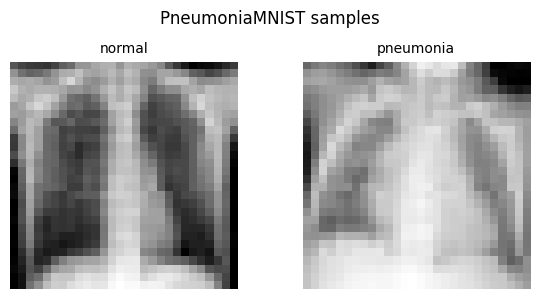

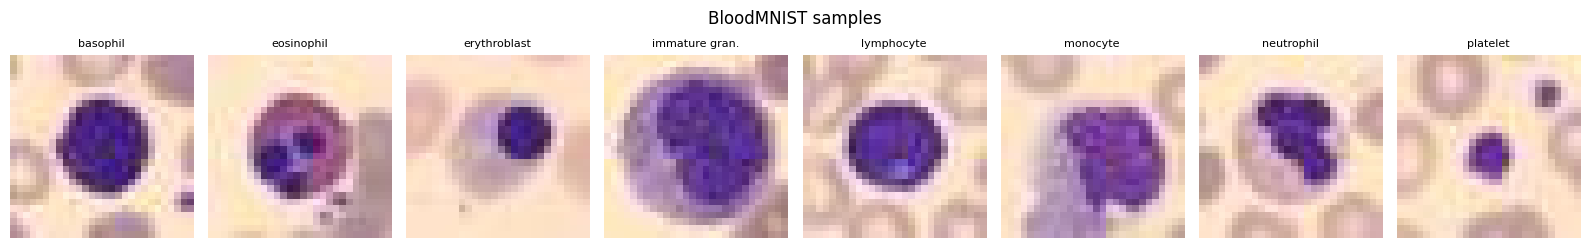

In [6]:
#look at sample images
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for i in range(2):
    idx = np.where(P_lbls == i)[0][0]
    axes[i].imshow(P_imgs[idx], cmap='gray')
    axes[i].set_title(pneu_classes[i], fontsize=10)
    axes[i].axis('off')
plt.suptitle('PneumoniaMNIST samples')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i in range(8):
    idx = np.where(B_lbls == i)[0][0]
    axes[i].imshow(B_imgs[idx])
    axes[i].set_title(blood_classes[i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('BloodMNIST samples')
plt.tight_layout(); plt.show()

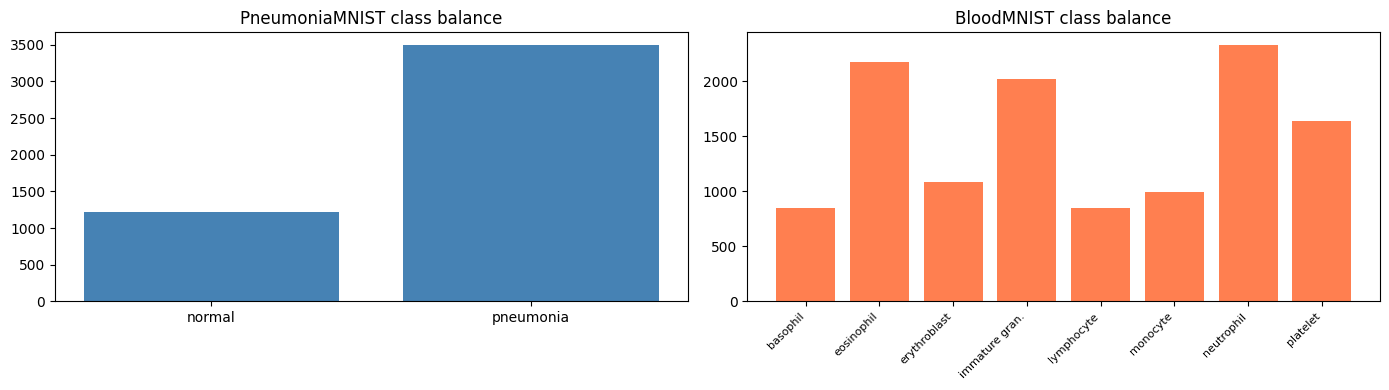

Pneumonia counts: {'normal': np.int64(1214), 'pneumonia': np.int64(3494)}
Blood counts: [ 852 2181 1085 2026  849  993 2330 1643]


In [7]:
#class balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(pneu_classes, np.bincount(P_lbls), color='steelblue')
ax1.set_title('PneumoniaMNIST class balance')

ax2.bar(range(8), np.bincount(B_lbls), color='coral')
ax2.set_xticks(range(8)); ax2.set_xticklabels(blood_classes, rotation=45, ha='right', fontsize=8)
ax2.set_title('BloodMNIST class balance')

plt.tight_layout(); plt.show()

print("Pneumonia counts:", dict(zip(pneu_classes, np.bincount(P_lbls))))
print("Blood counts:", np.bincount(B_lbls))

In [8]:
#feature summary
print("=== Input Feature Summary ===")
print(f"Pneumonia: {P_imgs.shape} | grayscale | MLP input = {28*28}")
print(f"  pixel mean {P_imgs.mean():.1f}, std {P_imgs.std():.1f}")
print(f"Blood: {B_imgs.shape} | RGB | MLP input = {28*28*3}")
print(f"  pixel mean {B_imgs.mean():.1f}, std {B_imgs.std():.1f}")
print("\nMissing values: none (MedMNIST is pre-cleaned)")

=== Input Feature Summary ===
Pneumonia: (4708, 28, 28) | grayscale | MLP input = 784
  pixel mean 145.8, std 42.9
Blood: (11959, 28, 28, 3) | RGB | MLP input = 2352
  pixel mean 182.8, std 52.8

Missing values: none (MedMNIST is pre-cleaned)


**ML**

In [9]:
#Random forest
# Flatten images into vectors and scale to 0-1
Xp_tr = P_imgs.reshape(len(P_imgs), -1) / 255.0
Xp_te = pneumonia_test.imgs.reshape(len(pneumonia_test.imgs), -1) / 255.0
yp_tr, yp_te = P_lbls, pneumonia_test.labels.flatten()

Xb_tr = B_imgs.reshape(len(B_imgs), -1) / 255.0
Xb_te = blood_test.imgs.reshape(len(blood_test.imgs), -1) / 255.0
yb_tr, yb_te = B_lbls, blood_test.labels.flatten()

# Random Forest on Pneumonia
print("Training Random Forest on Pneumonia...")
rf_p = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_p.fit(Xp_tr, yp_tr)
rf_p_acc = accuracy_score(yp_te, rf_p.predict(Xp_te))
rf_p_f1 = f1_score(yp_te, rf_p.predict(Xp_te), average='macro')
print(f"  Accuracy {rf_p_acc:.4f} | Macro F1 {rf_p_f1:.4f}")

# Random Forest on Blood
print("Training Random Forest on Blood...")
rf_b = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_b.fit(Xb_tr, yb_tr)
rf_b_acc = accuracy_score(yb_te, rf_b.predict(Xb_te))
rf_b_f1 = f1_score(yb_te, rf_b.predict(Xb_te), average='macro')
print(f"  Accuracy {rf_b_acc:.4f} | Macro F1 {rf_b_f1:.4f}")

Training Random Forest on Pneumonia...
  Accuracy 0.8526 | Macro F1 0.8294
Training Random Forest on Blood...
  Accuracy 0.8372 | Macro F1 0.8084


In [10]:
from sklearn.svm import LinearSVC

# Linear SVM on Pneumonia
print("Training Linear SVM on Pneumonia...")
svm_p = LinearSVC(random_state=42, max_iter=2000)
svm_p.fit(Xp_tr, yp_tr)
svm_p_acc = accuracy_score(yp_te, svm_p.predict(Xp_te))
svm_p_f1 = f1_score(yp_te, svm_p.predict(Xp_te), average='macro')
print(f"  Accuracy {svm_p_acc:.4f} | Macro F1 {svm_p_f1:.4f}")

# Linear SVM on Blood
print("Training Linear SVM on Blood...")
svm_b = LinearSVC(random_state=42, max_iter=2000)
svm_b.fit(Xb_tr, yb_tr)
svm_b_acc = accuracy_score(yb_te, svm_b.predict(Xb_te))
svm_b_f1 = f1_score(yb_te, svm_b.predict(Xb_te), average='macro')
print(f"  Accuracy {svm_b_acc:.4f} | Macro F1 {svm_b_f1:.4f}")

Training Linear SVM on Pneumonia...
  Accuracy 0.8253 | Macro F1 0.7910
Training Linear SVM on Blood...
  Accuracy 0.7977 | Macro F1 0.7777


In [11]:
from sklearn.svm import SVC
import time

# Proper RBF SVM on Pneumonia
print("Training RBF SVM on Pneumonia... (1-3 min)")
t = time.time()
svm_p = SVC(kernel='rbf', random_state=42)
svm_p.fit(Xp_tr, yp_tr)
svm_p_acc = accuracy_score(yp_te, svm_p.predict(Xp_te))
svm_p_f1 = f1_score(yp_te, svm_p.predict(Xp_te), average='macro')
print(f"  Accuracy {svm_p_acc:.4f} | Macro F1 {svm_p_f1:.4f} | {time.time()-t:.0f}s")

# Proper RBF SVM on Blood
print("Training RBF SVM on Blood... (this is the slow one, 10-30 min)")
t = time.time()
svm_b = SVC(kernel='rbf', random_state=42)
svm_b.fit(Xb_tr, yb_tr)
svm_b_acc = accuracy_score(yb_te, svm_b.predict(Xb_te))
svm_b_f1 = f1_score(yb_te, svm_b.predict(Xb_te), average='macro')
print(f"  Accuracy {svm_b_acc:.4f} | Macro F1 {svm_b_f1:.4f} | {time.time()-t:.0f}s")

Training RBF SVM on Pneumonia... (1-3 min)
  Accuracy 0.8542 | Macro F1 0.8291 | 7s
Training RBF SVM on Blood... (this is the slow one, 10-30 min)
  Accuracy 0.8471 | Macro F1 0.8229 | 236s


**MLP**

In [12]:
# Load validation splits (for tuning without touching test)
pneumonia_val = PneumoniaMNIST(split="val", download=True)
blood_val     = BloodMNIST(split="val", download=True)

# Pneumonia arrays
Xp_val = pneumonia_val.imgs.reshape(len(pneumonia_val.imgs), -1) / 255.0
yp_val = pneumonia_val.labels.flatten()

# Blood arrays
Xb_val = blood_val.imgs.reshape(len(blood_val.imgs), -1) / 255.0
yb_val = blood_val.labels.flatten()

# Standardise: subtract mean, divide by std (computed from TRAIN only)
def standardise(X_tr, *others):
    mean, std = X_tr.mean(0), X_tr.std(0) + 1e-8
    return [(X - mean) / std for X in (X_tr, *others)]

Xp_tr_s, Xp_val_s, Xp_te_s = standardise(Xp_tr, Xp_val, Xp_te)
Xb_tr_s, Xb_val_s, Xb_te_s = standardise(Xb_tr, Xb_val, Xb_te)

print("Standardised. Pneumonia train:", Xp_tr_s.shape, "| Blood train:", Xb_tr_s.shape)

Standardised. Pneumonia train: (4708, 784) | Blood train: (11959, 2352)


In [13]:
import copy

def train_good_mlp(X_tr, y_tr, X_val, y_val, input_size, num_classes,
                   h1=512, h2=256, dropout=0.3, lr=1e-3, batch_size=128,
                   max_epochs=100, patience=10):
    torch.manual_seed(42)
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr)),
        batch_size=batch_size, shuffle=True)

    model = nn.Sequential(
        nn.Linear(input_size, h1), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(h2, num_classes))
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    Xv = torch.FloatTensor(X_val)
    best_acc, best_state, wait, history = 0, None, 0, []

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(Xv).argmax(1).numpy()
        val_acc = accuracy_score(y_val, val_preds)
        history.append(val_acc)

        if val_acc > best_acc:
            best_acc, best_state, wait = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  early stop at epoch {epoch+1}")
                break

        if (epoch+1) % 5 == 0:
            print(f"  epoch {epoch+1}: val acc {val_acc:.4f} (best {best_acc:.4f})")

    model.load_state_dict(best_state)
    return model, history, best_acc

In [14]:
print("Training MLP on Pneumonia...")
mlp_p, hist_p, best_p = train_good_mlp(Xp_tr_s, yp_tr, Xp_val_s, yp_val,
                                       input_size=784, num_classes=2)

# Final test-set evaluation
mlp_p.eval()
with torch.no_grad():
    preds = mlp_p(torch.FloatTensor(Xp_te_s)).argmax(1).numpy()
mlp_p_acc = accuracy_score(yp_te, preds)
mlp_p_f1 = f1_score(yp_te, preds, average='macro')
print(f"\nPneumonia MLP — Test Accuracy {mlp_p_acc:.4f} | Macro F1 {mlp_p_f1:.4f}")

Training MLP on Pneumonia...
  epoch 5: val acc 0.9580 (best 0.9695)
  epoch 10: val acc 0.9542 (best 0.9695)
  early stop at epoch 14

Pneumonia MLP — Test Accuracy 0.8333 | Macro F1 0.8009


In [15]:
print("Retuning MLP on Pneumonia (gentler)...")
mlp_p, hist_p, best_p = train_good_mlp(
    Xp_tr_s, yp_tr, Xp_val_s, yp_val,
    input_size=784, num_classes=2,
    h1=512, h2=256,
    dropout=0.5,        # more dropout
    lr=3e-4,            # gentler learning rate
    batch_size=128,
    max_epochs=150,
    patience=25)        # more patience

mlp_p.eval()
with torch.no_grad():
    preds = mlp_p(torch.FloatTensor(Xp_te_s)).argmax(1).numpy()
mlp_p_acc = accuracy_score(yp_te, preds)
mlp_p_f1 = f1_score(yp_te, preds, average='macro')
print(f"\nPneumonia MLP — Test Accuracy {mlp_p_acc:.4f} | Macro F1 {mlp_p_f1:.4f}")

Retuning MLP on Pneumonia (gentler)...
  epoch 5: val acc 0.9561 (best 0.9637)
  epoch 10: val acc 0.9542 (best 0.9637)
  epoch 15: val acc 0.9599 (best 0.9637)
  epoch 20: val acc 0.9676 (best 0.9676)
  epoch 25: val acc 0.9637 (best 0.9676)
  epoch 30: val acc 0.9676 (best 0.9676)
  epoch 35: val acc 0.9656 (best 0.9676)
  epoch 40: val acc 0.9637 (best 0.9676)
  early stop at epoch 45

Pneumonia MLP — Test Accuracy 0.8510 | Macro F1 0.8253


In [16]:
print("Training MLP on Blood...")
mlp_b, hist_b, best_b = train_good_mlp(
    Xb_tr_s, yb_tr, Xb_val_s, yb_val,
    input_size=2352, num_classes=8,
    h1=512, h2=256,
    dropout=0.3,
    lr=1e-3,
    batch_size=128,
    max_epochs=150,
    patience=20)

mlp_b.eval()
with torch.no_grad():
    preds = mlp_b(torch.FloatTensor(Xb_te_s)).argmax(1).numpy()
mlp_b_acc = accuracy_score(yb_te, preds)
mlp_b_f1 = f1_score(yb_te, preds, average='macro')
print(f"\nBlood MLP — Test Accuracy {mlp_b_acc:.4f} | Macro F1 {mlp_b_f1:.4f}")

Training MLP on Blood...
  epoch 5: val acc 0.8464 (best 0.8598)
  epoch 10: val acc 0.8633 (best 0.8662)
  epoch 15: val acc 0.8721 (best 0.8750)
  epoch 20: val acc 0.8680 (best 0.8750)
  epoch 25: val acc 0.8703 (best 0.8750)
  epoch 30: val acc 0.8680 (best 0.8803)
  epoch 35: val acc 0.8668 (best 0.8803)
  epoch 40: val acc 0.8686 (best 0.8803)
  epoch 45: val acc 0.8709 (best 0.8803)
  epoch 50: val acc 0.8715 (best 0.8808)
  epoch 55: val acc 0.8657 (best 0.8808)
  epoch 60: val acc 0.8756 (best 0.8832)
  epoch 65: val acc 0.8750 (best 0.8832)
  epoch 70: val acc 0.8803 (best 0.8832)
  epoch 75: val acc 0.8826 (best 0.8832)
  early stop at epoch 77

Blood MLP — Test Accuracy 0.8623 | Macro F1 0.8461


In [17]:
print("Training MLP on Blood (wider: h1=1024)...")
mlp_b, hist_b, best_b = train_good_mlp(
    Xb_tr_s, yb_tr, Xb_val_s, yb_val,
    input_size=2352, num_classes=8,
    h1=1024, h2=256,    # wider first layer
    dropout=0.3,
    lr=1e-3,
    batch_size=128,
    max_epochs=150,
    patience=20)

mlp_b.eval()
with torch.no_grad():
    preds = mlp_b(torch.FloatTensor(Xb_te_s)).argmax(1).numpy()
mlp_b_acc = accuracy_score(yb_te, preds)
mlp_b_f1 = f1_score(yb_te, preds, average='macro')
print(f"\nBlood MLP (wide) — Test Accuracy {mlp_b_acc:.4f} | Macro F1 {mlp_b_f1:.4f}")

Training MLP on Blood (wider: h1=1024)...
  epoch 5: val acc 0.8581 (best 0.8633)
  epoch 10: val acc 0.8709 (best 0.8709)
  epoch 15: val acc 0.8797 (best 0.8803)
  epoch 20: val acc 0.8709 (best 0.8803)
  epoch 25: val acc 0.8692 (best 0.8803)
  epoch 30: val acc 0.8820 (best 0.8820)
  epoch 35: val acc 0.8727 (best 0.8820)
  epoch 40: val acc 0.8657 (best 0.8820)
  epoch 45: val acc 0.8586 (best 0.8820)
  early stop at epoch 50

Blood MLP (wide) — Test Accuracy 0.8571 | Macro F1 0.8358


In [18]:
print("Retraining best Blood MLP (h1=512)...")
mlp_b, hist_b, best_b = train_good_mlp(
    Xb_tr_s, yb_tr, Xb_val_s, yb_val,
    input_size=2352, num_classes=8,
    h1=512, h2=256, dropout=0.3, lr=1e-3,
    batch_size=128, max_epochs=150, patience=20)

mlp_b.eval()
with torch.no_grad():
    preds = mlp_b(torch.FloatTensor(Xb_te_s)).argmax(1).numpy()
mlp_b_acc = accuracy_score(yb_te, preds)
mlp_b_f1 = f1_score(yb_te, preds, average='macro')
print(f"\nBlood MLP (final) — Test Accuracy {mlp_b_acc:.4f} | Macro F1 {mlp_b_f1:.4f}")

Retraining best Blood MLP (h1=512)...
  epoch 5: val acc 0.8464 (best 0.8598)
  epoch 10: val acc 0.8633 (best 0.8662)
  epoch 15: val acc 0.8721 (best 0.8750)
  epoch 20: val acc 0.8680 (best 0.8750)
  epoch 25: val acc 0.8703 (best 0.8750)
  epoch 30: val acc 0.8680 (best 0.8803)
  epoch 35: val acc 0.8668 (best 0.8803)
  epoch 40: val acc 0.8686 (best 0.8803)
  epoch 45: val acc 0.8709 (best 0.8803)
  epoch 50: val acc 0.8715 (best 0.8808)
  epoch 55: val acc 0.8657 (best 0.8808)
  epoch 60: val acc 0.8756 (best 0.8832)
  epoch 65: val acc 0.8750 (best 0.8832)
  epoch 70: val acc 0.8803 (best 0.8832)
  epoch 75: val acc 0.8826 (best 0.8832)
  early stop at epoch 77

Blood MLP (final) — Test Accuracy 0.8623 | Macro F1 0.8461


In [20]:
print("="*60)
print(f"{'Model':<18}{'Pneu Acc':>10}{'Pneu F1':>10}{'Blood Acc':>11}{'Blood F1':>10}")
print("="*60)
print(f"{'Random Forest':<18}{rf_p_acc:>10.3f}{rf_p_f1:>10.3f}{rf_b_acc:>11.3f}{rf_b_f1:>10.3f}")
print(f"{'RBF SVM':<18}{svm_p_acc:>10.3f}{svm_p_f1:>10.3f}{svm_b_acc:>11.3f}{svm_b_f1:>10.3f}")
print(f"{'MLP (tuned)':<18}{mlp_p_acc:>10.3f}{mlp_p_f1:>10.3f}{mlp_b_acc:>11.3f}{mlp_b_f1:>10.3f}")
print("="*60)

Model               Pneu Acc   Pneu F1  Blood Acc  Blood F1
Random Forest          0.853     0.829      0.837     0.808
RBF SVM                0.854     0.829      0.847     0.823
MLP (tuned)            0.851     0.825      0.862     0.846
